In [3]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
from sentiment_analysis import get_sentiment

PROJECT_ID = "insurance-backed-securities"   # <-- fill in
DATASET    = "Securities"      # <-- fill in

client = bigquery.Client(project=PROJECT_ID)
print(f"Connected to project: {client.project}")

Loading FinBERT model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT ready.
Connected to project: insurance-backed-securities


/Users/arthuracker/anaconda3/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [4]:
tables = list(client.list_tables(f"{PROJECT_ID}.{DATASET}"))
for t in tables:
    print(t.table_id)

Agg_Fixed_Field
Agg_Spread_Long
Asset_Cashflows


In [5]:
query = f"""
SELECT * 
FROM `{PROJECT_ID}.{DATASET}.Agg_Fixed_Field`
WHERE Issuer = "Walt Disney Co/The"
"""

agg_fixed_fields_long = client.query(query).to_dataframe()
print(f"agg_fixed_fields_long shape: {agg_fixed_fields_long.shape}")
agg_fixed_fields_long.head()

/Users/arthuracker/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


agg_fixed_fields_long shape: (1, 16)


,CUSIP,Amt Out,Cpn,Maturity,BBG Composite,Mac Dur _Ask_,ISSUER,CPN_FREQ,RTG_MOODY,BICS_LEVEL_1_SECTOR_NAME,BICS_LEVEL_2_INDUSTRY_GROUP_NAME,string_field_11,string_field_12,string_field_13,string_field_14,string_field_15
0,254687FQ4,1250000000,3.8,2030-03-22,A,3.721376,Walt Disney Co/The,2,A2,Communications,Entertainment Content,None,None,None,None,None


In [6]:
query = f"""
SELECT * 
FROM `{PROJECT_ID}.{DATASET}.Agg_Spread_Long`
WHERE CUSIP = '254687FQ4'
"""

agg_spread_long = client.query(query).to_dataframe()
print(f"agg_spread_long shape: {agg_spread_long.shape}")
agg_spread_long.head()

/Users/arthuracker/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


agg_spread_long shape: (499, 3)


,Date,CUSIP,Spread
0,2024-03-01,254687FQ4,58.377804
1,2024-03-04,254687FQ4,59.777661
2,2024-03-05,254687FQ4,60.859469
3,2024-03-06,254687FQ4,57.842818
4,2024-03-07,254687FQ4,58.112232


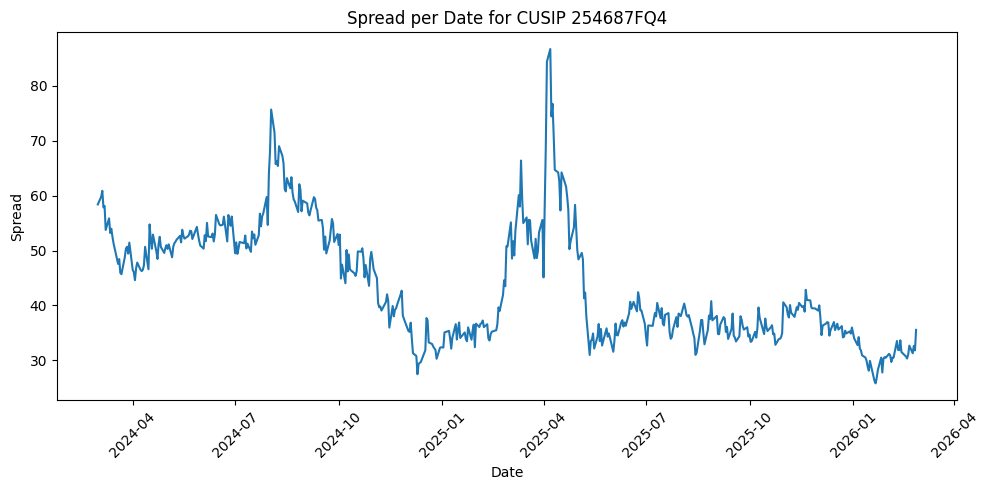

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(agg_spread_long["Date"], agg_spread_long["Spread"], linestyle='-')
plt.title("Spread per Date for CUSIP 254687FQ4")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
from sentiment_analysis import get_sentiment

# Ensure Date is datetime
agg_spread_long["Date"] = pd.to_datetime(agg_spread_long["Date"])

# Determine weekly bins from start to end
start_date = agg_spread_long["Date"].min().date()
end_date = agg_spread_long["Date"].max().date()

# Generate list of week start dates
week_starts = pd.date_range(start=start_date, end=end_date, freq="W-MON")

sentiment_results = []
for week_start in week_starts:
    week_end = week_start + pd.Timedelta(days=6)
    print(f"\nFetching sentiment for Walt Disney: {week_start} to {week_end}")
    df = get_sentiment(
        company_names=["Walt Disney"],
        start_date=week_start.strftime("%Y-%m-%d"),
        end_date=week_end.strftime("%Y-%m-%d"),
        max_results=20,
    )
    df["week_start"] = week_start
    sentiment_results.append(df)

# Concatenate all results
weekly_sentiment_df = pd.concat(sentiment_results, ignore_index=True)
print(f"weekly_sentiment_df shape: {weekly_sentiment_df.shape}")
weekly_sentiment_df.head()


Fetching sentiment for Walt Disney: 2024-03-04 00:00:00 to 2024-03-10 00:00:00
  Walt Disney → DIS
  [Alpaca] Fetching news for DIS (2024-03-04 -> 2024-03-10)...
  [Alpaca] Fetched 20 articles total.
  Scoring 20 headlines with FinBERT...
  Mean sentiment score: +0.3468

Fetching sentiment for Walt Disney: 2024-03-11 00:00:00 to 2024-03-17 00:00:00
  Walt Disney → DIS
  [Alpaca] Fetching news for DIS (2024-03-11 -> 2024-03-17)...
  [Alpaca] Fetched 15 articles total.
  Scoring 15 headlines with FinBERT...
  Mean sentiment score: -0.0817

Fetching sentiment for Walt Disney: 2024-03-18 00:00:00 to 2024-03-24 00:00:00
  Walt Disney → DIS
  [Alpaca] Fetching news for DIS (2024-03-18 -> 2024-03-24)...
  [Alpaca] Fetched 20 articles total.
  Scoring 20 headlines with FinBERT...
  Mean sentiment score: +0.1396

Fetching sentiment for Walt Disney: 2024-03-25 00:00:00 to 2024-03-31 00:00:00
  Walt Disney → DIS
  [Alpaca] Fetching news for DIS (2024-03-25 -> 2024-03-31)...
  [Alpaca] Fetched 20

,symbol,headline,url,created_at,author,source,summary,positive,negative,neutral,score,label,week_start
0,news,Oprah Winfrey To Spotlight Weight Loss Drugs I...,https://www.benzinga.com/general/entertainment...,2024-03-08 21:59:05+00:00,Chris Katje,benzinga,Weight loss drugs could get an increased spotl...,0.1365,0.0198,0.8438,0.1167,neutral,2024-03-04
1,news,Disney CEO Iger Says On Activist Investors: Wo...,https://www.benzinga.com/news/24/03/37568120/d...,2024-03-08 20:36:21+00:00,Benzinga Newsdesk,benzinga,,0.5054,0.0910,0.4036,0.4145,positive,2024-03-04
2,news,Disney CEO Iger Says ESPN To Continue To 'Take...,https://www.benzinga.com/news/24/03/37568115/d...,2024-03-08 20:35:53+00:00,Benzinga Newsdesk,benzinga,,0.7309,0.0067,0.2625,0.7242,positive,2024-03-04
3,news,Disney CEO Iger Says Co Plans To Turbocharge G...,https://www.benzinga.com/news/24/03/37568095/d...,2024-03-08 20:35:09+00:00,Benzinga Newsdesk,benzinga,,0.8874,0.0080,0.1046,0.8794,positive,2024-03-04
4,news,Disney CEO Iger Says 'We Have Great People Run...,https://www.benzinga.com/news/24/03/37568089/d...,2024-03-08 20:34:41+00:00,Benzinga Newsdesk,benzinga,,0.9576,0.0182,0.0242,0.9395,positive,2024-03-04


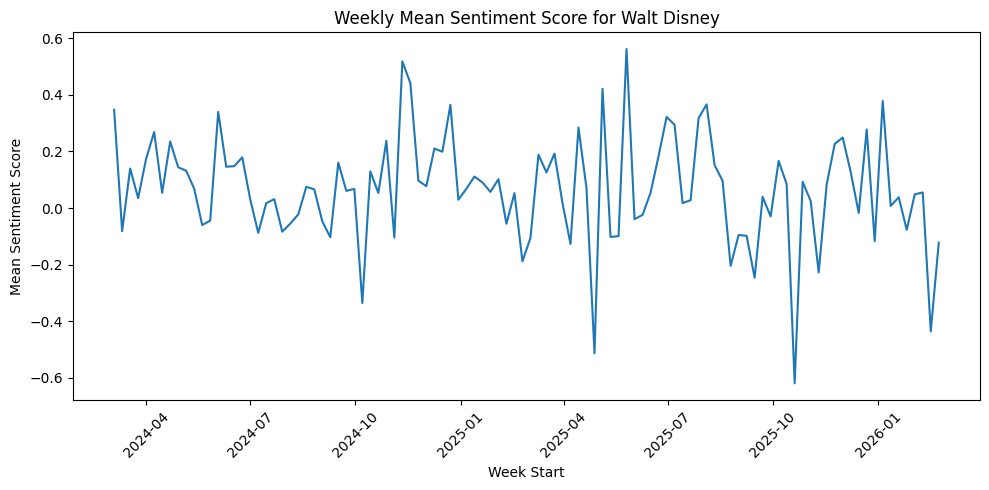

In [10]:
import matplotlib.pyplot as plt

# Group by week_start and calculate mean sentiment score for each week
weekly_score = (
    weekly_sentiment_df.groupby("week_start")["score"]
    .mean()
    .reset_index()
    .sort_values("week_start")
)

plt.figure(figsize=(10, 5))
plt.plot(weekly_score["week_start"], weekly_score["score"], linestyle="-")
plt.xticks(rotation=45)
plt.title("Weekly Mean Sentiment Score for Walt Disney")
plt.xlabel("Week Start")
plt.ylabel("Mean Sentiment Score")
plt.tight_layout()
plt.show()

/var/folders/pd/p6wbrsxj001b9dpkltbn2mxh0000gn/T/ipykernel_68646/1870349543.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(merged["week_start"], rotation=45)


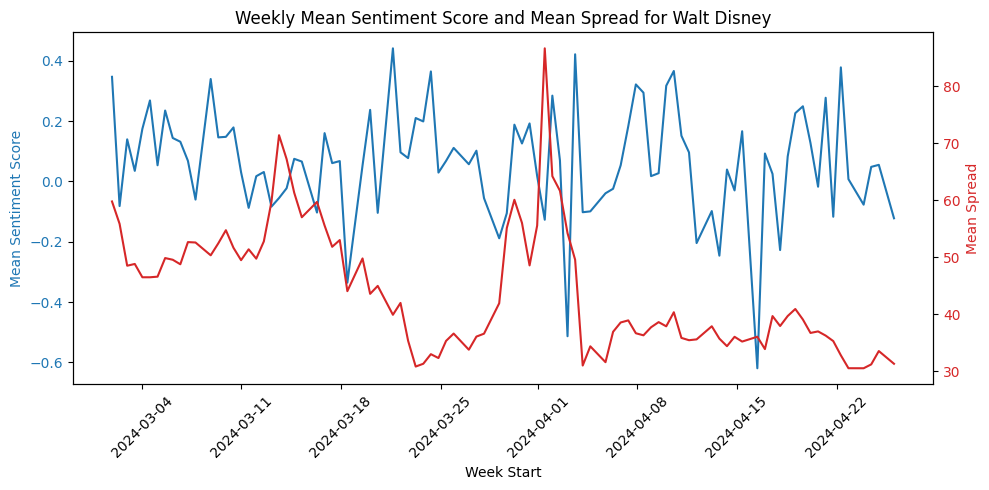

In [11]:
import matplotlib.pyplot as plt

# Merge weekly_score and agg_spread_long on 'week_start' and 'Date'
# Make sure 'week_start' and 'Date' are both datetime.date for matching

# If 'Date' is datetime64[ns], convert to .date
agg_spread_long["Date"] = pd.to_datetime(agg_spread_long["Date"]).dt.date
weekly_score["week_start"] = pd.to_datetime(weekly_score["week_start"]).dt.date

# We'll align: for each week, avg the spread over that week
spread_weekly = (
    agg_spread_long.groupby("Date")["Spread"].mean().reset_index()
)
spread_weekly = spread_weekly.rename(columns={"Date": "week_start", "Spread": "mean_spread"})

# Align to weekly bins by grouping by week_start
merged = pd.merge(weekly_score, spread_weekly, on="week_start", how="inner")

fig, ax1 = plt.subplots(figsize=(10, 5))

color = "tab:blue"
ax1.set_xlabel("Week Start")
ax1.set_ylabel("Mean Sentiment Score", color=color)
ax1.plot(merged["week_start"], merged["score"], color=color, label="Mean Sentiment Score")
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_xticklabels(merged["week_start"], rotation=45)

ax2 = ax1.twinx()

color = "tab:red"
ax2.set_ylabel("Mean Spread", color=color)
ax2.plot(merged["week_start"], merged["mean_spread"], color=color, label="Mean Spread")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Weekly Mean Sentiment Score and Mean Spread for Walt Disney")
fig.tight_layout()
plt.show()